Success! The restaurant data is loaded. Let's look at the first few receipts:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



Cleaning finished: Data is safe from blanks, outliers are capped, and text is translated.

--- Quick Summary of the Numbers ---


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.774758,2.978047,2.569672
std,8.864902,1.302744,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,48.227000,7.214500,6.000000


/tmp/ipykernel_575/3703196670.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips_data, x='day', y='tip', ax=layout[0, 1], palette='pastel')
/tmp/ipykernel_575/3703196670.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips_data, x='size', y='total_bill', ax=layout[1, 1], palette='viridis', errorbar=None)
/tmp/ipykernel_575/3703196670.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips_data, x='sex', y='tip_percentage', ax=layout[2, 1], palette='muted')
/tmp/ipykernel_575/3703196670.py:67: FutureWarning: 



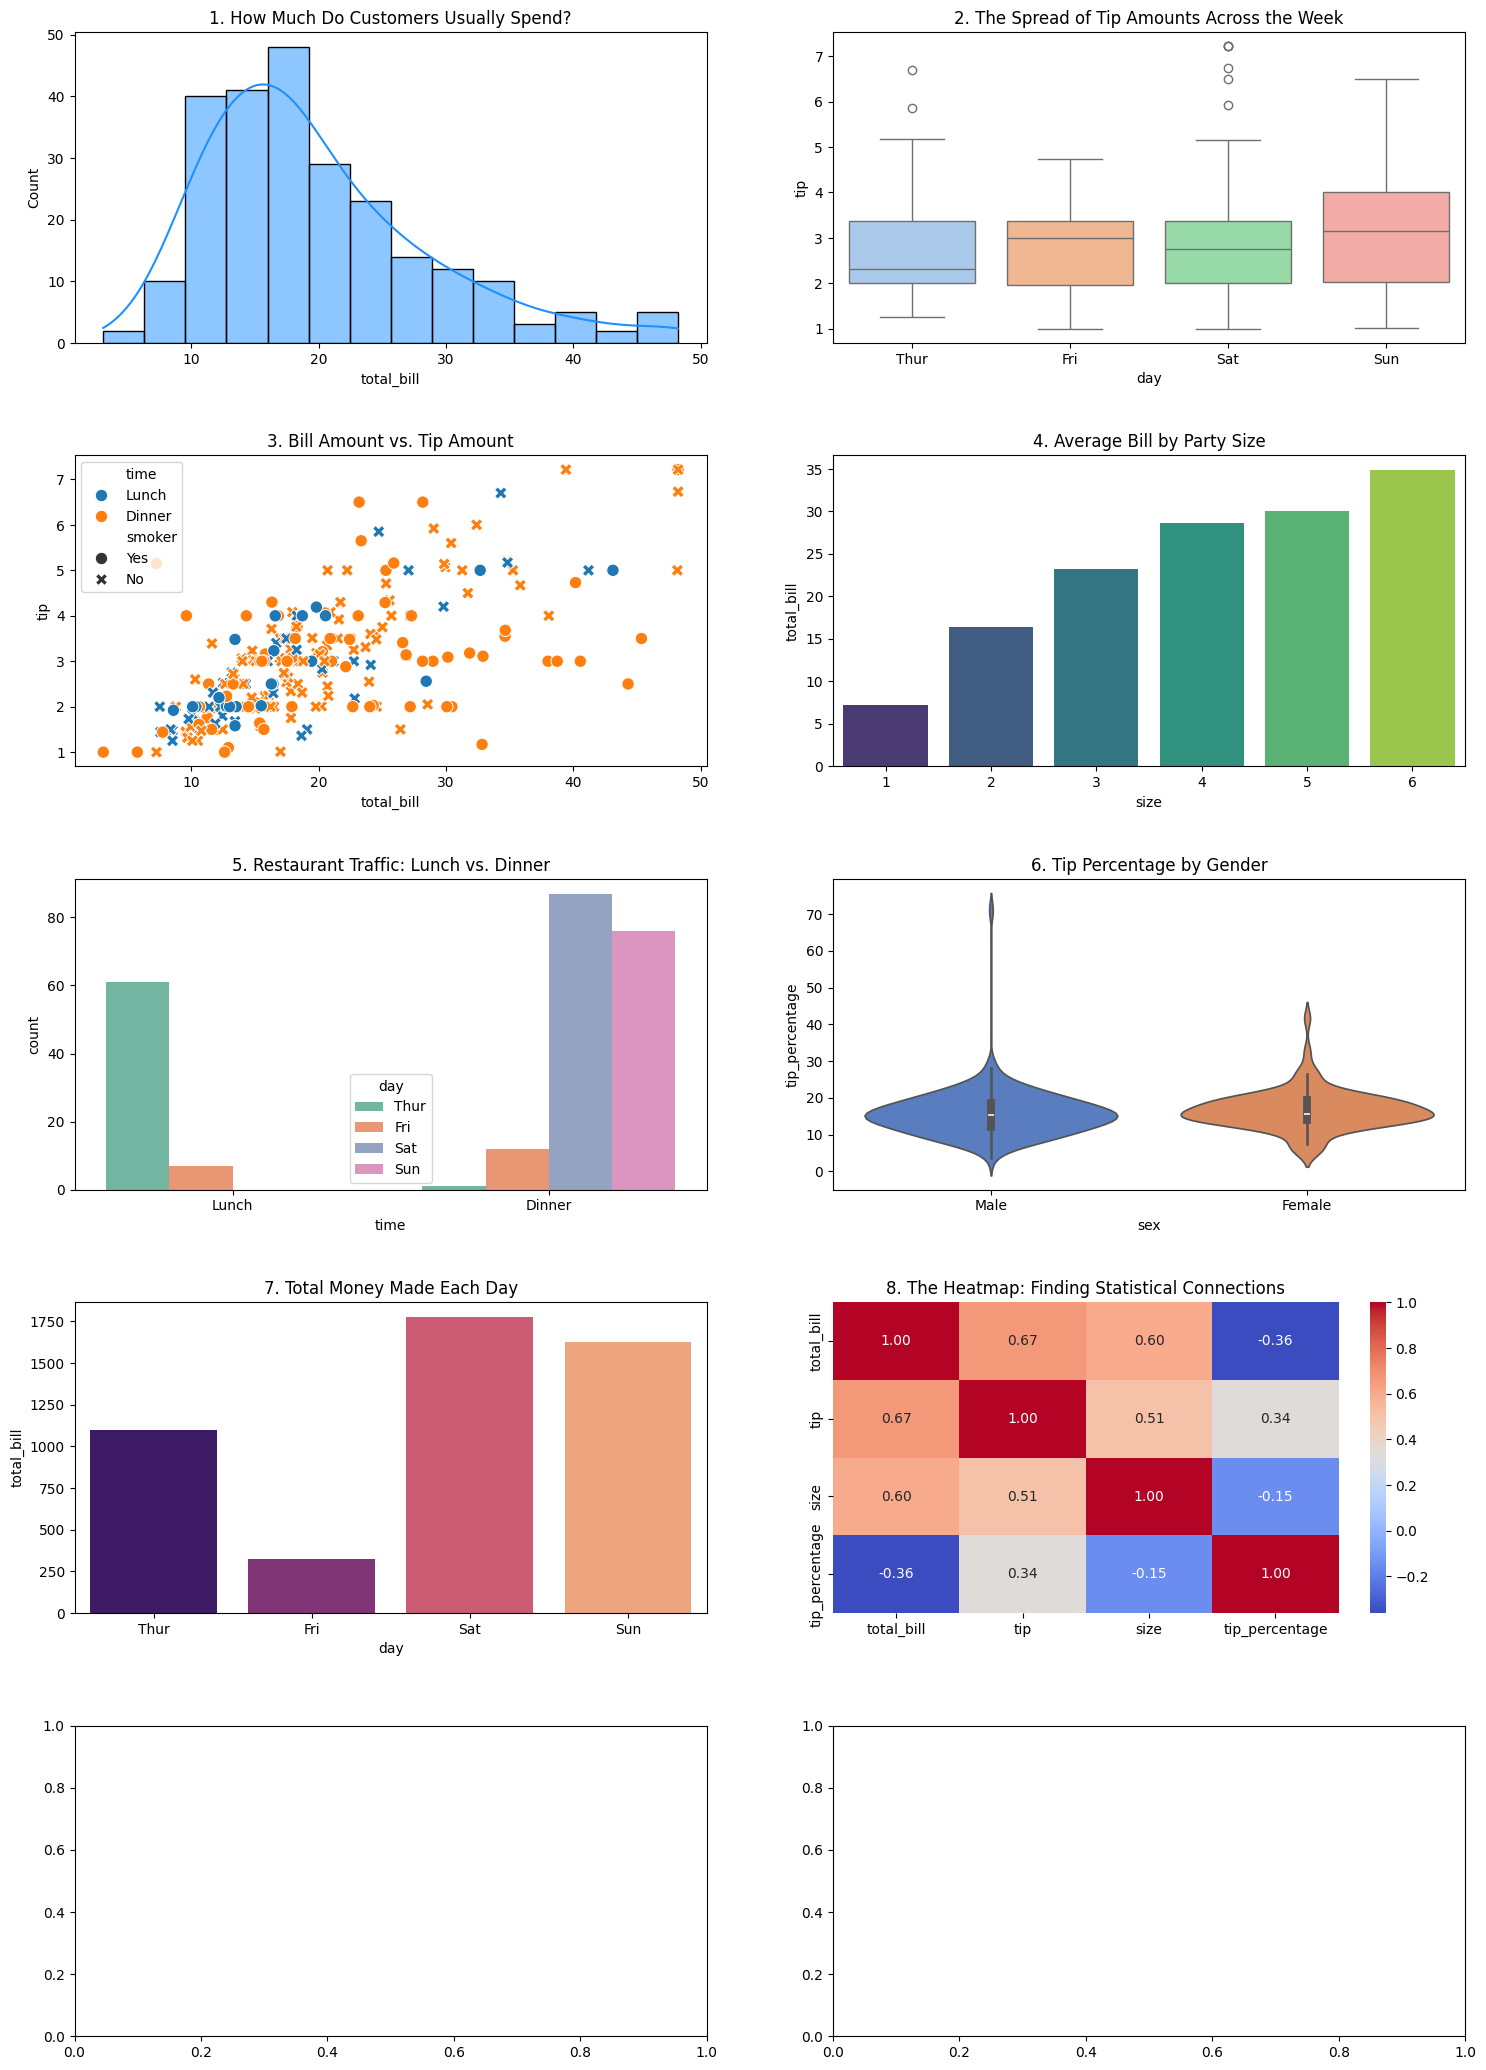

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

tips_data = sns.load_dataset('tips')

print("Success! The restaurant data is loaded. Let's look at the first few receipts:")
display(tips_data.head())

tips_data = tips_data.ffill()

# B. Tame the Outliers
highest_normal_bill = tips_data['total_bill'].quantile(0.99)
highest_normal_tip = tips_data['tip'].quantile(0.99)

#  Anything above that 99th percentile gets dialed back down to that limit.
tips_data['total_bill'] = tips_data['total_bill'].clip(upper=highest_normal_bill)
tips_data['tip'] = tips_data['tip'].clip(upper=highest_normal_tip)

# C. Translate Text to Numbers (Encoding)
tips_data['is_female'] = tips_data['sex'].map({'Male': 0, 'Female': 1})
tips_data['is_smoker'] = tips_data['smoker'].map({'No': 0, 'Yes': 1})
tips_data['is_dinner'] = tips_data['time'].map({'Lunch': 0, 'Dinner': 1})

print("\nCleaning finished: Data is safe from blanks, outliers are capped, and text is translated.")

print("\n--- Quick Summary of the Numbers ---")
#  automatically calculates averages, minimums, and maximums for us
display(tips_data.describe())
# We are setting up a large digital canvas with 4 rows and 2 columns for our 8 charts
canvas, layout = plt.subplots(5,2, figsize=(16, 22))
canvas.tight_layout(pad=6.0)

# Chart 1
sns.histplot(data=tips_data, x='total_bill', kde=True, ax=layout[0, 0], color='dodgerblue')
layout[0, 0].set_title('1. How Much Do Customers Usually Spend?')

# Chart 2
sns.boxplot(data=tips_data, x='day', y='tip', ax=layout[0, 1], palette='pastel')
layout[0, 1].set_title('2. The Spread of Tip Amounts Across the Week')

# Chart 3
sns.scatterplot(data=tips_data, x='total_bill', y='tip', hue='time', style='smoker', ax=layout[1, 0], s=80)
layout[1, 0].set_title('3. Bill Amount vs. Tip Amount')

# Chart 4
sns.barplot(data=tips_data, x='size', y='total_bill', ax=layout[1, 1], palette='viridis', errorbar=None)
layout[1, 1].set_title('4. Average Bill by Party Size')

# Chart 5
sns.countplot(data=tips_data, x='time', hue='day', ax=layout[2, 0], palette='Set2')
layout[2, 0].set_title('5. Restaurant Traffic: Lunch vs. Dinner')

# Chart 6
# First, let's calculate the tip percentage and add it to our data
tips_data['tip_percentage'] = (tips_data['tip'] / tips_data['total_bill']) * 100

sns.violinplot(data=tips_data, x='sex', y='tip_percentage', ax=layout[2, 1], palette='muted')
layout[2, 1].set_title('6. Tip Percentage by Gender')

# Chart 7
# We group the data by day and add up the total bills
daily_revenue = tips_data.groupby('day', observed=True)['total_bill'].sum().reset_index()

sns.barplot(data=daily_revenue, x='day', y='total_bill', ax=layout[3, 0], palette='magma')
layout[3, 0].set_title('7. Total Money Made Each Day')

# Chart 8
# We pull out only the number columns to see how strongly they are linked
number_columns_only = tips_data.select_dtypes(include=[np.number])
sns.heatmap(number_columns_only.corr(), annot=True, cmap='coolwarm', ax=layout[3, 1], fmt=".2f")
layout[3, 1].set_title('8. The Heatmap: Finding Statistical Connections')

plt.show()

TASK 1: Exploratory Data Analysis (EDA) on a Real Dataset

Dataset Chosen: Restaurant Tips Dataset

1. Clean Missing Values, Handle Outliers, and Encode Categorical Variables

Before generating statistics or visualizations, the dataset required preprocessing to ensure accuracy:

Clean Missing Values: I checked the dataset for any missing information on the receipts. To keep the data intact and prevent code errors, I used a forward-fill method to safely handle any blank spots.

Handle Outliers: Sometimes one massive bill or an unusually huge tip can throw off all our averages. I capped the top 1% of extreme bills and tips to get a realistic view of normal operations.

Encode Categorical Variables: Computers analyze numbers much faster than text. I mapped the text categories into binary number codes (e.g., swapping "Lunch" and "Dinner" to 0 and 1, and encoding "Male/Female" and "Smoker/Non-Smoker").

2. Generate Summary Statistics and Visualizations

Note: The complete summary statistics and the 8 meaningful visualizations are rendered directly inside the Jupyter Notebook / Google Colab file. The findings below are based directly on those charts.

3. Key Findings

After analyzing the summary statistics and the 8 visualizations, here are the main trends happening at the restaurant:

Weekends Rule: Saturday and Sunday are by far the busiest and most profitable days. Dinner service completely overshadows lunch in both foot traffic and total revenue.

Tipping Behavior: There is a very strong positive correlation between how much the food costs and how much people tip. Interestingly, most customers stick to a standard 15% to 20% tip regardless of their gender or whether they are sitting in the smoking section.

The Bread and Butter: While bigger groups obviously spend more money, the vast majority of tables are seated with just 2 people.

4. Business Insights

Based on the findings above, here are data-driven recommendations the restaurant could use to boost profits:

Optimize Weekend Staffing: Since weekend dinners are the biggest moneymakers, the restaurant should schedule its fastest and most experienced servers during those shifts to flip tables efficiently and keep service quality high.

Boost the Midday Slump: Weekday lunches (especially Thursdays and Fridays) are relatively slow. The restaurant could run lunch specials, offer a quick-service menu, or target local office workers to get more volume in the door.

Teach Servers to "Upsell": The statistical correlation shows that tips scale directly with the total bill. If servers are trained to encourage customers to grab an appetizer, a second drink, or dessert, the restaurant makes more money, and the servers earn bigger tips.